### Pharmaceutical Supply Chain Risk Prediction System
#### Overview
- Drug shortages are a critical failure of the pharmaceutical supply chain, leading to treatment delays and increased costs  
- This project builds a risk prediction system using FDA drug shortage data to identify products at high risk of supply disruption

#### Business Problem

Disruptions can arise due to:

- Manufacturing quality issues  
- Supplier concentration  
- Regulatory delays  
- Product lifecycle vulnerabilities  

Most current systems detect shortages only after they occur.

##### This project addresses:
- Can we **predict supply disruptions before they happen?**
- Can we **quantify risk to support proactive decision-making?**

In [2]:
#importing all requirements

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

c:\Users\hansi\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
#load json file
with open('drug-shortages.json') as f:
    data = json.load(f)

#extract actual records
df = pd.json_normalize(data['results'])

#### Preview dataset


In [4]:
df.head()

,update_type,initial_posting_date,package_ndc,generic_name,contact_info,availability,update_date,therapeutic_category,dosage_form,presentation,...,related_info,shortage_reason,openfda.nui,openfda.pharm_class_epc,openfda.pharm_class_moa,openfda.pharm_class_cs,change_date,resolved_note,openfda.pharm_class_pe,related_info_link
0,Revised,10/12/2022,57844-117-01,"Amphetamine Aspartate Monohydrate, Amphetamine...",800-545-8800,Available,04/01/2026,[Psychiatry],Tablet,"Adderall, Tablet, 1.875 mg; 1.875 mg; 1.875 mg...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,New,10/27/2025,0310-6615-02,Pramlintide Acetate Injection,800-236-9933,NaN,10/27/2025,[Endocrinology/Metabolism],Injection,"SymlinPen® 60 , Injection, 1000 ug/1 mL (NDC 0...",...,Discontinuation of the manufacture of the drug.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Reverified,03/23/2018,63323-285-13,Ropivacaine Hydrochloride Injection,888-386-1300,Unavailable,04/02/2026,[Anesthesia],Injection,"Naropin, Injection, 2 mg/1 mL (NDC 63323-285-13)",...,Next release March 2026. Check wholesalers for...,Demand increase for the drug,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,New,06/09/2025,66215-101-03,Bosentan Tablet,800-526-7736,NaN,06/09/2025,[Cardiovascular],Tablet,"Tracleer, Tablet, 62.5 mg (NDC 66215-101-03)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Revised,06/13/2018,55150-251-10,Lidocaine Hydrochloride Injection,888-238-7880,Unavailable,03/18/2026,[Anesthesia],Injection,"Lidocaine Hydrochloride, Injection, 10 mg/mL (...",...,On backorder. Recovery: TBD. Check wholesalers...,Demand increase for the drug,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(1705, 36)

In [6]:
df.columns

Index(['update_type', 'initial_posting_date', 'package_ndc', 'generic_name',
       'contact_info', 'availability', 'update_date', 'therapeutic_category',
       'dosage_form', 'presentation', 'company_name', 'status',
       'openfda.application_number', 'openfda.brand_name',
       'openfda.generic_name', 'openfda.manufacturer_name',
       'openfda.product_ndc', 'openfda.product_type', 'openfda.route',
       'openfda.substance_name', 'openfda.rxcui', 'openfda.spl_id',
       'openfda.spl_set_id', 'openfda.package_ndc', 'openfda.unii',
       'discontinued_date', 'related_info', 'shortage_reason', 'openfda.nui',
       'openfda.pharm_class_epc', 'openfda.pharm_class_moa',
       'openfda.pharm_class_cs', 'change_date', 'resolved_note',
       'openfda.pharm_class_pe', 'related_info_link'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   update_type                 1705 non-null   object
 1   initial_posting_date        1705 non-null   object
 2   package_ndc                 1705 non-null   object
 3   generic_name                1705 non-null   object
 4   contact_info                1705 non-null   object
 5   availability                1146 non-null   object
 6   update_date                 1705 non-null   object
 7   therapeutic_category        1705 non-null   object
 8   dosage_form                 1694 non-null   object
 9   presentation                1705 non-null   object
 10  company_name                1705 non-null   object
 11  status                      1705 non-null   object
 12  openfda.application_number  1528 non-null   object
 13  openfda.brand_name          1545 non-null   obje

In [8]:
#need to find where the data is unique
#checking if package_ndc is unique: no it isn't
df['package_ndc'].nunique()

1686

In [9]:
counts = df['package_ndc'].value_counts()
counts

package_ndc
0409-4916-14    2
25021-311-10    2
0555-9131-67    2
0409-4900-14    2
0409-5534-14    2
               ..
59310-822-06    1
63323-488-37    1
0093-0109-10    1
55150-225-05    1
0409-9137-05    1
Name: count, Length: 1686, dtype: int64

In [10]:
#checking 2 records with same package ndc

df[df['package_ndc'] == '0409-4903-34']

,update_type,initial_posting_date,package_ndc,generic_name,contact_info,availability,update_date,therapeutic_category,dosage_form,presentation,...,related_info,shortage_reason,openfda.nui,openfda.pharm_class_epc,openfda.pharm_class_moa,openfda.pharm_class_cs,change_date,resolved_note,openfda.pharm_class_pe,related_info_link
47,New,11/07/2025,0409-4903-34,Lidocaine Hydrochloride Injection,844-646-4398,NaN,11/07/2025,"[Analgesia/Addiction, Pediatric]",Injection,"Lidocaine Hydrochloride, Injection, 2%, USP (F...",...,Discontinuation of the manufacture of the drug,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
674,Reverified,02/22/2012,0409-4903-34,Lidocaine Hydrochloride Injection,844-646-4398,Unavailable,03/27/2026,"[Anesthesia, Pediatric]",Injection,"Lidocaine Hydrochloride, Injection, 100 mg/5mL...",...,Discontinuation of the manufacture of the drug,Discontinuation of the manufacture of the drug,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://www.accessdata.fda.gov/scripts/drugsho...


#### Cleaning the data

- Standardize categorical values
- Clean text fields
- Convert date fields
- Remove duplicate records

In [11]:
#removing unnecessary columns, creating new dataframe

dff = df[[
'package_ndc',
'generic_name',
'dosage_form',
'presentation',
'company_name',
'initial_posting_date',
'update_date',
'discontinued_date',
'availability',
'status',
'shortage_reason',
'therapeutic_category',
'update_type',
'related_info'
]]

dff.head()

,package_ndc,generic_name,dosage_form,presentation,company_name,initial_posting_date,update_date,discontinued_date,availability,status,shortage_reason,therapeutic_category,update_type,related_info
0,57844-117-01,"Amphetamine Aspartate Monohydrate, Amphetamine...",Tablet,"Adderall, Tablet, 1.875 mg; 1.875 mg; 1.875 mg...","Teva Pharmaceuticals USA, Inc.",10/12/2022,04/01/2026,NaN,Available,Current,NaN,[Psychiatry],Revised,NaN
1,0310-6615-02,Pramlintide Acetate Injection,Injection,"SymlinPen® 60 , Injection, 1000 ug/1 mL (NDC 0...",AstraZeneca AB,10/27/2025,10/27/2025,10/27/2025,NaN,To Be Discontinued,NaN,[Endocrinology/Metabolism],New,Discontinuation of the manufacture of the drug.
2,63323-285-13,Ropivacaine Hydrochloride Injection,Injection,"Naropin, Injection, 2 mg/1 mL (NDC 63323-285-13)","Fresenius Kabi USA, LLC",03/23/2018,04/02/2026,NaN,Unavailable,Current,Demand increase for the drug,[Anesthesia],Reverified,Next release March 2026. Check wholesalers for...
3,66215-101-03,Bosentan Tablet,Tablet,"Tracleer, Tablet, 62.5 mg (NDC 66215-101-03)",Actelion Pharmaceuticals,06/09/2025,06/09/2025,06/09/2025,NaN,To Be Discontinued,NaN,[Cardiovascular],New,NaN
4,55150-251-10,Lidocaine Hydrochloride Injection,Injection,"Lidocaine Hydrochloride, Injection, 10 mg/mL (...",Eugia US LLC,06/13/2018,03/18/2026,NaN,Unavailable,Current,Demand increase for the drug,[Anesthesia],Revised,On backorder. Recovery: TBD. Check wholesalers...


In [12]:
dff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1705 entries, 0 to 1704
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   package_ndc           1705 non-null   object
 1   generic_name          1705 non-null   object
 2   dosage_form           1694 non-null   object
 3   presentation          1705 non-null   object
 4   company_name          1705 non-null   object
 5   initial_posting_date  1705 non-null   object
 6   update_date           1705 non-null   object
 7   discontinued_date     517 non-null    object
 8   availability          1146 non-null   object
 9   status                1705 non-null   object
 10  shortage_reason       422 non-null    object
 11  therapeutic_category  1705 non-null   object
 12  update_type           1705 non-null   object
 13  related_info          1136 non-null   object
dtypes: object(14)
memory usage: 186.6+ KB


In [13]:
#cleaning column names
dff.columns = dff.columns.str.strip()

In [14]:
#checking for missing values
dff.isnull().sum()

package_ndc                0
generic_name               0
dosage_form               11
presentation               0
company_name               0
initial_posting_date       0
update_date                0
discontinued_date       1188
availability             559
status                     0
shortage_reason         1283
therapeutic_category       0
update_type                0
related_info             569
dtype: int64

In [15]:
#fixing date columns

dff['initial_posting_date'] = pd.to_datetime(dff['initial_posting_date'])
dff['update_date'] = pd.to_datetime(dff['update_date'])
dff['discontinued_date'] = pd.to_datetime(dff['discontinued_date'])


<ipython-input-15-888f1865422a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['initial_posting_date'] = pd.to_datetime(dff['initial_posting_date'])
<ipython-input-15-888f1865422a>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['update_date'] = pd.to_datetime(dff['update_date'])
<ipython-input-15-888f1865422a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

##### Categorical Columns
The columns which consist of values that belong to a defined set  
Need to make sure there are no spelling or any other errors causing duplication

In [16]:
dff['availability'].unique()

array(['Available', nan, 'Unavailable', 'Limited Availability',
       'Avaliable', 'Limited Availablity', 'Information pending',
       'Limited Availabiltiy'], dtype=object)

In [17]:
dff['availability'] = dff['availability'].str.strip().str.title()

<ipython-input-17-b16c1fc9d2cc>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['availability'] = dff['availability'].str.strip().str.title()


In [18]:
dff['availability'] = dff['availability'].replace({
    'Avaliable' : 'Available', 'Limited Availablity' : 'Limited Availability', 'Limited Availabiltiy' : 'Limited Availability'})

dff['availability'].unique()

<ipython-input-18-59bdb59d8528>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['availability'] = dff['availability'].replace({


array(['Available', nan, 'Unavailable', 'Limited Availability',
       'Information Pending'], dtype=object)

In [19]:
dff['status'].unique()

array(['Current', 'To Be Discontinued', 'Resolved'], dtype=object)

In [20]:
dff['status'] = dff['status'].str.strip().str.title()

<ipython-input-20-4a95eb10270a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['status'] = dff['status'].str.strip().str.title()


In [21]:
dff['shortage_reason'].unique()

array([nan, 'Demand increase for the drug',
       'Delay in shipping of the drug',
       'Shortage of an active ingredient',
       'Discontinuation of the manufacture of the drug', 'Other',
       'Requirements related to complying with good manufacturing practices',
       'Shortage of an inactive ingredient component', 'Regulatory delay'],
      dtype=object)

In [22]:
dff['shortage_reason'] = dff['shortage_reason'].fillna('Unavailable')
dff['shortage_reason'].unique()

<ipython-input-22-5f81479052e2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['shortage_reason'] = dff['shortage_reason'].fillna('Unavailable')


array(['Unavailable', 'Demand increase for the drug',
       'Delay in shipping of the drug',
       'Shortage of an active ingredient',
       'Discontinuation of the manufacture of the drug', 'Other',
       'Requirements related to complying with good manufacturing practices',
       'Shortage of an inactive ingredient component', 'Regulatory delay'],
      dtype=object)

In [23]:
dff['package_ndc'] = dff['package_ndc'].str.strip()
dff['generic_name'] = dff['generic_name'].str.strip()
dff['dosage_form'] = dff['dosage_form'].str.strip()
dff['presentation'] = dff['presentation'].str.strip()
dff['company_name'] = dff['company_name'].str.strip()
dff['generic_name'] = dff['generic_name'].str.strip()
dff['availability'] = dff['availability'].str.strip()
dff['status'] = dff['status'].str.strip()
dff['shortage_reason'] = dff['shortage_reason'].str.strip()
dff['update_type'] = dff['update_type'].str.strip()
dff['related_info'] = dff['related_info'].str.strip()

<ipython-input-23-ed6bf92faf62>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['package_ndc'] = dff['package_ndc'].str.strip()
<ipython-input-23-ed6bf92faf62>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['generic_name'] = dff['generic_name'].str.strip()
<ipython-input-23-ed6bf92faf62>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [24]:
#column has a list
dff['therapeutic_category'] = dff['therapeutic_category'].apply(
    lambda x: ', '.join(x) if isinstance(x, list) else x
)

<ipython-input-24-1973fae2ff10>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dff['therapeutic_category'] = dff['therapeutic_category'].apply(


In [25]:
dff.duplicated(subset=['package_ndc', 'update_date']).sum()

1

In [26]:
dff = dff.drop_duplicates(subset=['package_ndc', 'update_date'])

In [27]:
#sort the table by date, and remove duplicate rows 
#duplicates = same ndc, multiple instances of shortages
#we are only keeping the latest shortage instance

dff = dff.sort_values(by = 'update_date', ascending=False)
df_latest = dff.drop_duplicates(subset = 'package_ndc', keep= 'first')

In [28]:
df_latest.shape

(1686, 14)

In [29]:
df_latest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1686 entries, 480 to 1634
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   package_ndc           1686 non-null   object        
 1   generic_name          1686 non-null   object        
 2   dosage_form           1675 non-null   object        
 3   presentation          1686 non-null   object        
 4   company_name          1686 non-null   object        
 5   initial_posting_date  1686 non-null   datetime64[ns]
 6   update_date           1686 non-null   datetime64[ns]
 7   discontinued_date     503 non-null    datetime64[ns]
 8   availability          1142 non-null   object        
 9   status                1686 non-null   object        
 10  shortage_reason       1686 non-null   object        
 11  therapeutic_category  1686 non-null   object        
 12  update_type           1686 non-null   object        
 13  related_info         

#### EDA

In [30]:
#what are the different dosages?

df_latest['dosage_form'].unique()

array(['Injection', 'Capsule', 'Tablet, Chewable', 'Tablet',
       'Oral Suspension', 'Concentrate', 'Oral Solution', 'Vaginal Gel',
       'Gel', 'Ophthalmic Solution', 'Solution', 'Irrigant', 'Spray',
       'Powder, For Solution', 'Ophthalmic Ointment', 'Topical Gel',
       'Capsule, Extended Release', 'Film, Extended Release', nan,
       'Transdermal System', 'Lotion', 'Syrup', 'Nasal Spray',
       'Injectable Suspension', 'Patch', 'Ring', 'Gel; Gel, Metered',
       'Powder', 'Oral Powder', 'Cream', 'Topical Powder'], dtype=object)

In [31]:
#what are the different availabilities?

df_latest['availability'].unique()

array(['Available', 'Unavailable', 'Limited Availability', nan,
       'Information Pending'], dtype=object)

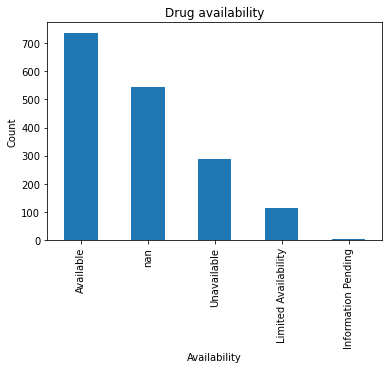

In [32]:
#plotting availability to check distribution

df_latest['availability'].value_counts(dropna=False).plot(kind='bar')
plt.title('Drug availability')
plt.xlabel('Availability')
plt.ylabel('Count')
plt.show()

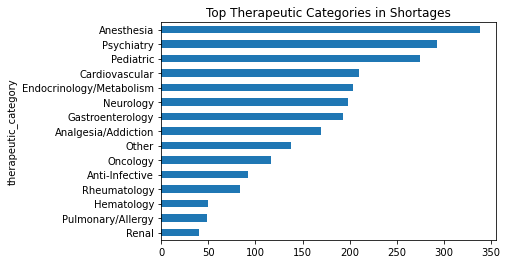

In [33]:
#plotting categories to check distribution
#theraputic category is a list, need to break it down

df_temp = df_latest.copy()
df_temp = df_temp.assign(
    therapeutic_category = df_temp['therapeutic_category'].str.split(', ')
).explode('therapeutic_category')

df_temp['therapeutic_category'].value_counts().head(15).sort_values().plot(kind='barh')
plt.title('Top Therapeutic Categories in Shortages')
plt.show()

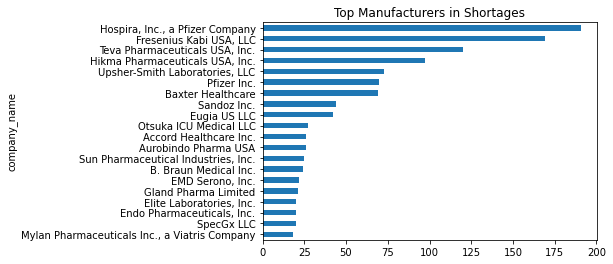

In [34]:
#plotting manufacturers to check distribution

df_latest['company_name'].value_counts().head(20).sort_values().plot(kind='barh')
plt.title('Top Manufacturers in Shortages')
plt.show()

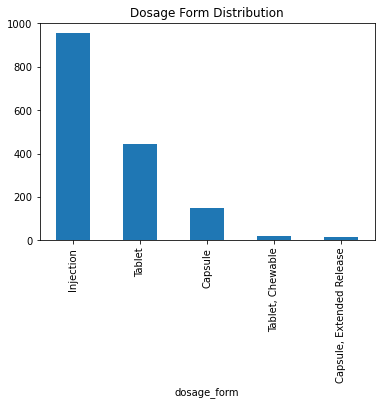

In [35]:
#plotting dosage form to check distribution

df_latest['dosage_form'].value_counts().head(5).plot(kind='bar')
plt.title('Dosage Form Distribution')
plt.show()

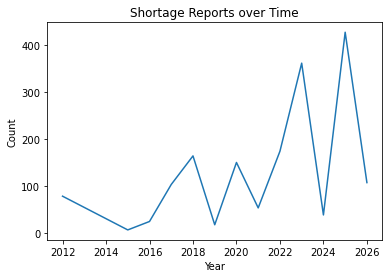

In [36]:
#plotting a line chart to see shoratges over time

dff['initial_posting_date'].dt.year.value_counts().sort_index().plot()
plt.title('Shortage Reports over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

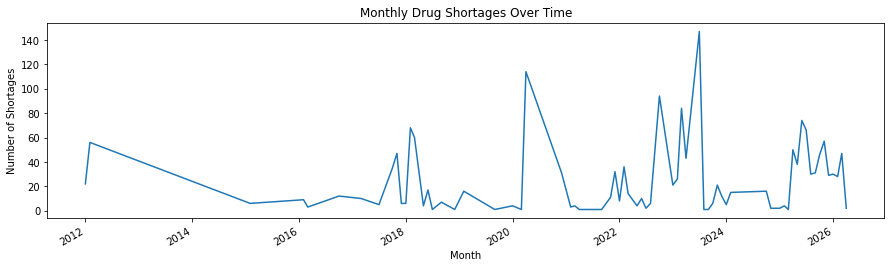

In [37]:
#checking monthly trends of shortages to see if there are any patterns

dff['month_year'] = dff['initial_posting_date'].dt.to_period('M')
monthly_counts = dff['month_year'].value_counts().sort_index()
monthly_counts.index = monthly_counts.index.to_timestamp()

monthly_counts.plot(figsize=(15, 4))
plt.title('Monthly Drug Shortages Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Shortages')
plt.show()

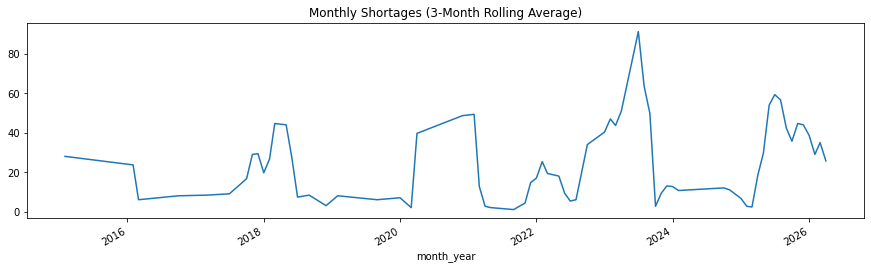

In [38]:
#checking the three month rolling average

monthly_counts.rolling(3).mean().plot(figsize=(15,4))
plt.title('Monthly Shortages (3-Month Rolling Average)')
plt.show()

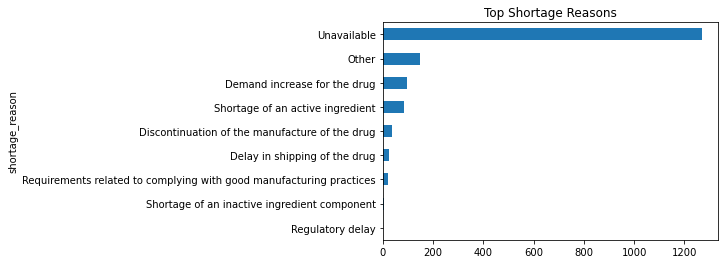

In [39]:
#plotting shortage reasons to check distribution

df_latest['shortage_reason'].value_counts().head(10).sort_values().plot(kind='barh')
plt.title('Top Shortage Reasons')
plt.show()

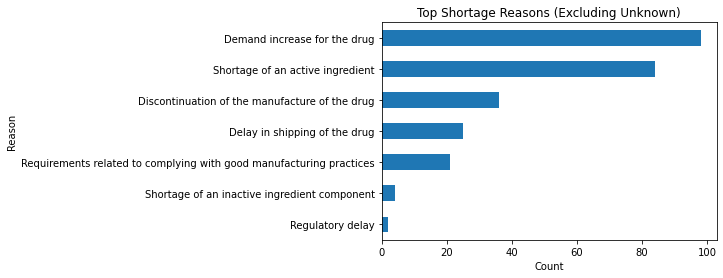

In [40]:
#plotting the chart again after removing unknown

df_filtered = df_latest[~df_latest['shortage_reason'].isin(['Unavailable', 'Other'])]
df_filtered['shortage_reason'].value_counts().head(10).sort_values().plot(kind='barh')

plt.title('Top Shortage Reasons (Excluding Unknown)')
plt.xlabel('Count')
plt.ylabel('Reason')
plt.show()

#### Creating Features

**Target Variable Definition**

The target variable **shortage** is defined as:
- **1 → Shortage**
  - Includes:
    - Unavailable
    - Limited Availability

- **0 → No Shortage**
  - Includes:
    - All other availability statuses  


In [41]:
#creating a shortage column

df_latest['availability'].unique()

array(['Available', 'Unavailable', 'Limited Availability', nan,
       'Information Pending'], dtype=object)

In [42]:
#1 = there is shortage, 0 = no shortage

def define_shortage(x):
    if pd.isna(x):
        return 0
    elif x in ['Unavailable', 'Limited Availability']:
        return 1
    else:
        return 0

df_latest['shortage'] = df_latest['availability'].apply(define_shortage)

<ipython-input-42-08fb205a829a>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_latest['shortage'] = df_latest['availability'].apply(define_shortage)


In [43]:
df_latest['shortage'].value_counts()

shortage
0    1284
1     402
Name: count, dtype: int64

**Manufacturer Count** (Supply-Side Proxy):

The number of unique manufacturers per drug using historical data.

This represents:
- Supplier diversification
- Supply chain resilience

Note:
This is derived from shortage dataset only and does not not reflect full market supply

In [44]:
#Creating a manufacturer count column
#using dff, not df_latest
#need the historical count here

manufacturer_count = dff.groupby('generic_name')['company_name'].nunique()
manufacturer_count

generic_name
Acetaminophen; Oxycodone Hydrochloride Tablet    1
Adalimumab-adaz Injection                        1
Adalimumab-afzb Injection                        1
Adalimumab-ryvk Kit                              1
Adefovir Dipivoxil Tablet                        1
                                                ..
Vecuronium Bromide Injection                     1
Verapamil Hydrochloride Injection                1
Vigabatrin Oral Solution                         1
Voriconazole Injection                           1
Voriconazole Tablet                              1
Name: company_name, Length: 243, dtype: int64

In [45]:
#adding the column to df_latest

manufacturer_count = manufacturer_count.reset_index()
manufacturer_count.columns = ['generic_name', 'manufacturer_count']

df_latest = df_latest.merge(manufacturer_count, on = 'generic_name', how = 'left')

In [46]:
df_latest[['generic_name', 'manufacturer_count']].drop_duplicates().head(10)

,generic_name,manufacturer_count
0,Dextrose Monohydrate 5% Injection,4
1,Ropivacaine Hydrochloride Injection,5
2,Lidocaine Hydrochloride Injection,10
3,Lisdexamfetamine Dimesylate Capsule,13
4,Atropine Sulfate Injection,7
6,"Lisdexamfetamine Dimesylate Tablet, Chewable",3
7,Sterile Water Injection,5
8,"Bupivacaine Hydrochloride, Epinephrine Bitartr...",2
9,Ketorolac Tromethamine Injection,7
10,Lorazepam Injection,4


In [47]:
#checking the distribution of manufacturer count

df_latest['manufacturer_count'].describe()

count    1686.000000
mean        4.958482
std         3.925954
min         1.000000
25%         1.000000
50%         4.000000
75%         7.000000
max        14.000000
Name: manufacturer_count, dtype: float64

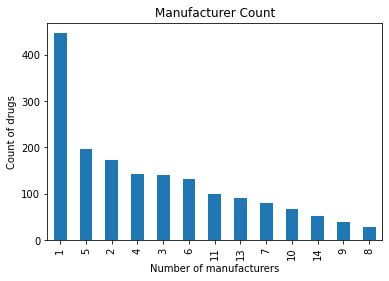

In [48]:
#plotting it

df_latest['manufacturer_count'].sort_values().value_counts(dropna=False).plot(kind='bar')
plt.title('Manufacturer Count')
plt.xlabel('Number of manufacturers')
plt.ylabel('Count of drugs')
plt.show()

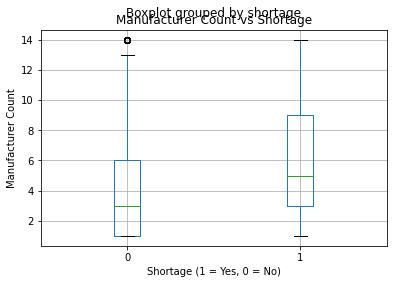

In [49]:
#expectation: less number of manufacturers, more shortage
#reality: drugs with shortages have more manufacturers

#WHY?
#1. high demand drugs have more manufacturers
#2. complex drugs have more manufacturers but still fail - need to check if they are 'complex'
#3. data is biased - only has shortage data


df_latest.boxplot(column = 'manufacturer_count', by = 'shortage')
plt.title('Manufacturer Count vs Shortage')
plt.xlabel('Shortage (1 = Yes, 0 = No)')
plt.ylabel('Manufacturer Count')
plt.show()


In [50]:
df_latest.groupby('shortage')['manufacturer_count'].mean()

shortage
0    4.523364
1    6.348259
Name: manufacturer_count, dtype: float64

**Shortage Frequency:**

Package-level frequency was explored but found to be limited,
as NDCs do not consistently capture repeated shortage events

Drug-level aggregation is therefore used instead

In [51]:
#creating shortage frequency column
#Has this drug historically been unstable?

shortage_freq = dff.groupby('package_ndc').size()

In [52]:
shortage_freq = shortage_freq.reset_index()
shortage_freq.columns = ['package_ndc', 'shortage_frequency']

In [53]:
df_latest = df_latest.merge(shortage_freq, on = 'package_ndc', how = 'left')

In [54]:
df_latest[['package_ndc', 'shortage_frequency']].head()

,package_ndc,shortage_frequency
0,65219-460-20,1
1,65219-632-20,1
2,63323-492-37,1
3,47781-564-01,1
4,0517-1001-25,1


In [55]:
df_latest.groupby('shortage')['shortage_frequency'].mean()

shortage
0    1.003115
1    1.034826
Name: shortage_frequency, dtype: float64

In [56]:
#NDC does not appear multiple times
#trying the same with name

drug_freq = df.groupby('generic_name').size().reset_index(name='drug_shortage_frequency')

df_latest = df_latest.merge(drug_freq, on='generic_name', how='left')

In [57]:
df_latest.groupby('shortage')['drug_shortage_frequency'].mean()

shortage
0    24.102804
1    33.731343
Name: drug_shortage_frequency, dtype: float64

In [58]:
#normalizing distribution
#for logistic regression

df_latest['log_drug_freq'] = np.log1p(df_latest['drug_shortage_frequency'])

**Drug Complexity (Heuristic Feature):**

Drug complexity is approximated using dosage form:

- High → injections, IV drugs  
- Medium → specialized delivery (ophthalmic, transdermal)  
- Low → oral forms (tablets, capsules)  

This serves as a proxy for manufacturing complexity

In [59]:
#defining drug complexity 
#based on dosage form

def dosage_complexity(x):
    x = str(x).lower()
    
    if any(term in x for term in ['injection', 'injectable', 'iv']):
        return 'High'
    elif any(term in x for term in ['ophthalmic', 'transdermal', 'nasal', 'spray', 'gel', 'cream']):
        return 'Medium'
    elif any(term in x for term in ['tablet', 'capsule', 'syrup', 'solution', 'oral']):
        return 'Low'
    else:
        return 'Medium'

df_latest['complexity'] = df_latest['dosage_form'].apply(dosage_complexity) 

In [60]:
df_latest.groupby('shortage')['complexity'].value_counts(normalize='True')

shortage  complexity
0         High          0.535826
          Low           0.424455
          Medium        0.039720
1         High          0.669154
          Low           0.298507
          Medium        0.032338
Name: proportion, dtype: float64

In [61]:
df_latest = pd.get_dummies(df_latest, columns=['complexity'], drop_first=True)

In [62]:
df_latest.columns

Index(['package_ndc', 'generic_name', 'dosage_form', 'presentation',
       'company_name', 'initial_posting_date', 'update_date',
       'discontinued_date', 'availability', 'status', 'shortage_reason',
       'therapeutic_category', 'update_type', 'related_info', 'shortage',
       'manufacturer_count', 'shortage_frequency', 'drug_shortage_frequency',
       'log_drug_freq', 'complexity_Low', 'complexity_Medium'],
      dtype='object')

#### Modeling Approach (Baseline)

A Logistic Regression model is used as a baseline:

- Interpretable
- Suitable for binary classification
- Helps understand feature impact

In [63]:
#creating new df for modeling

cols_to_drop = [
    'package_ndc', 
    'generic_name', 
    'dosage_form', 
    'presentation',
    'company_name', 
    'initial_posting_date', 
    'update_date',
    'discontinued_date', 
    'availability', 
    'status', 
    'shortage_reason',
    'therapeutic_category', 
    'update_type', 
    'related_info', 
    'shortage_frequency'
]
df_model = df_latest.drop(columns=cols_to_drop)

In [64]:
df_model.columns

Index(['shortage', 'manufacturer_count', 'drug_shortage_frequency',
       'log_drug_freq', 'complexity_Low', 'complexity_Medium'],
      dtype='object')

#### Logistic Regression

In [65]:
#split x and y
#target var = shortage 

x = df_model.drop(columns=['shortage'])
y=df_model['shortage']

In [66]:
#train test split
#80% data = learn, 20% = test

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [67]:
#train model

model = LogisticRegression(max_iter = 1000, class_weight='balanced')
model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [68]:
#predictions

y_pred = model.predict(x_test)

In [69]:
#probabilities
#above 0.6 → high risk

y_prob = model.predict_proba(x_test)[:, 1]
y_pred_new = (y_prob > 0.6).astype(int)

In [70]:
#evlauate
#accuracy

accuracy_score(y_test, y_pred_new)

0.6568047337278107

In [71]:
#confusion matrix

confusion_matrix(y_test, y_pred_new)

array([[198,  58],
       [ 58,  24]], dtype=int64)

In [72]:
#classification report

classification_report(y_test, y_pred_new)

'              precision    recall  f1-score   support\n\n           0       0.77      0.77      0.77       256\n           1       0.29      0.29      0.29        82\n\n    accuracy                           0.66       338\n   macro avg       0.53      0.53      0.53       338\nweighted avg       0.66      0.66      0.66       338\n'

In [73]:
#interpret 

coefficients = pd.DataFrame({
    'Feature': x.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
2,log_drug_freq,0.655621
4,complexity_Medium,0.647195
0,manufacturer_count,0.098757
1,drug_shortage_frequency,-0.016122
3,complexity_Low,-0.553236


In [74]:
for t in [0.4, 0.5, 0.6, 0.7]:
    y_pred_temp = (y_prob > t).astype(int)
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_temp))


Threshold: 0.4
[[ 95 161]
 [  8  74]]

Threshold: 0.5
[[125 131]
 [ 18  64]]

Threshold: 0.6
[[198  58]
 [ 58  24]]

Threshold: 0.7
[[241  15]
 [ 79   3]]


#### Output Dataset

The cleaned dataset is exported:

- 2: Orange Book data
- 3: Integrating and final modeling

This dataset includes:
- Target variable (shortage)
- Engineered features

In [75]:
#storing df as csv

df_latest.to_csv('shortage_data.csv', index=False)

##### Next Steps
- This dataset creates the **target variable for modeling**
- Additional features will be introduced from:
  - **2: FDA Orange Book dataset**
- Final modeling will be performed on:
  - **3: Combined dataset (1 + 2)**